In [ ]:
#importing libraries needed for the project
import numpy as numpy
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
import string
import nltk
from nltk.corpus import stopwords
from wordcloud import WordCloud
nltk.download('stopwords')

import tensorflow as tf 
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

import warnings
warnings.filterwarnings('ignore')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Aadam\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [20]:
training_data = pd.read_csv('emails.csv')
training_data.head(20)

,Unnamed: 0,label,text,label_num
0,605,ham,Subject: enron methanol ; meter # : 988291\r\n...,0
1,2349,ham,"Subject: hpl nom for january 9 , 2001\r\n( see...",0
2,3624,ham,"Subject: neon retreat\r\nho ho ho , we ' re ar...",0
3,4685,spam,"Subject: photoshop , windows , office . cheap ...",1
4,2030,ham,Subject: re : indian springs\r\nthis deal is t...,0
5,2949,ham,Subject: ehronline web address change\r\nthis ...,0
6,2793,ham,Subject: spring savings certificate - take 30 ...,0
7,4185,spam,Subject: looking for medication ? we ` re the ...,1
8,2641,ham,Subject: noms / actual flow for 2 / 26\r\nwe a...,0
9,1870,ham,"Subject: nominations for oct . 21 - 23 , 2000\...",0


In [21]:
#view dimensions of training data
training_data.shape

(5171, 4)

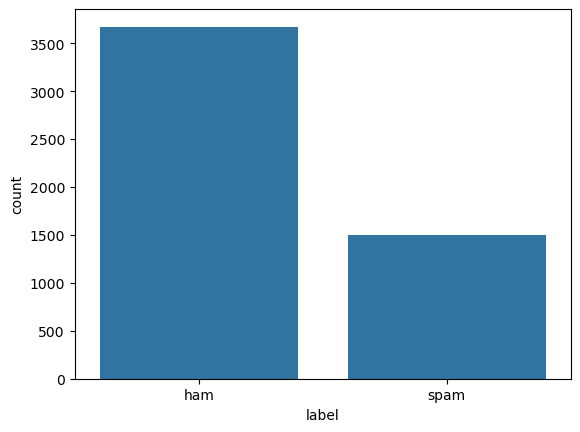

In [22]:
sns.countplot(x='label', data=training_data)#make a count plot as per label of spam or ham
plt.show()

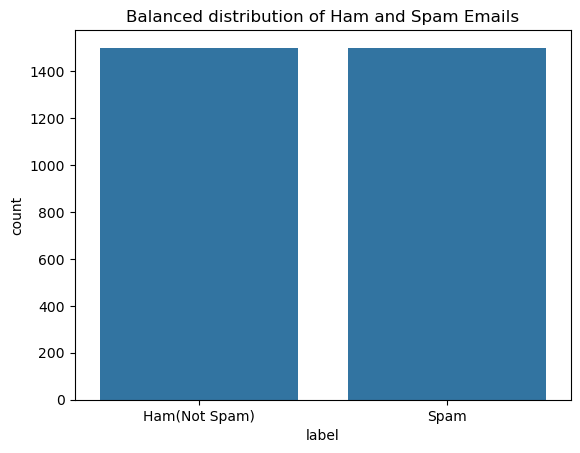

In [23]:
ham_msg = training_data[training_data.label == 'ham']
spam_msg = training_data[training_data.label == 'spam']
ham_msg_balanced= ham_msg.sample(n=len(spam_msg), random_state=0)
balanced_data = pd.concat([ham_msg_balanced, spam_msg]).reset_index(drop=True)

sns.countplot(x='label', data=balanced_data)
plt.title('Balanced distribution of Ham and Spam Emails')
plt.xticks(ticks=[0,1], labels=['Ham(Not Spam)', 'Spam'])
plt.show()


In [24]:
balanced_data

,Unnamed: 0,label,text,label_num
0,2786,ham,Subject: imbalance gas\r\njust in case worse c...,0
1,957,ham,Subject: new nomination - tejas\r\n- - - - - -...,0
2,446,ham,Subject: bpa rate case - seasonal rates\r\n- -...,0
3,2506,ham,Subject: valero ' s february gas nominations\r...,0
4,1168,ham,"Subject: plant outage affecting "" meter # 8291...",0
...,...,...,...,...
2993,4381,spam,Subject: pictures\r\nstreamlined denizen ajar ...,1
2994,4979,spam,Subject: penny stocks are about timing\r\nnoma...,1
2995,4162,spam,Subject: anomaly boys from 3881\r\nuosda apapr...,1
2996,4365,spam,Subject: slutty milf wants to meet you\r\ntake...,1


In [25]:
balanced_data['text'] = balanced_data['text'].str.replace('Subject', '')

In [28]:
balanced_data.head(5)

,Unnamed: 0,label,text,label_num
0,2786,ham,: imbalance gas\r\njust in case worse comes to...,0
1,957,ham,: new nomination - tejas\r\n- - - - - - - - - ...,0
2,446,ham,: bpa rate case - seasonal rates\r\n- - - - - ...,0
3,2506,ham,: valero ' s february gas nominations\r\ndaren...,0
4,1168,ham,": plant outage affecting "" meter # 8291 "" enro...",0


In [29]:
punctuations_list= string.punctuation
def remove_punctuations(text):
    temp = str.maketrans('','', punctuations_list)
    return text.translate(temp)
balanced_data['text'] = balanced_data['text'].apply(lambda x: remove_punctuations(x))
balanced_data.head()

,Unnamed: 0,label,text,label_num
0,2786,ham,imbalance gas\r\njust in case worse comes to ...,0
1,957,ham,new nomination tejas\r\n ...,0
2,446,ham,bpa rate case seasonal rates\r\n ...,0
3,2506,ham,valero s february gas nominations\r\ndaren ...,0
4,1168,ham,plant outage affecting meter 8291 enron me...,0


In [30]:
def remove_stopwords(text):
    stop_words = stopwords.words('english')

    imp_words = []

    # Storing the important words
    for word in str(text).split():
        word = word.lower()

        if word not in stop_words:
            imp_words.append(word)

    output = " ".join(imp_words)

    return output


balanced_data['text'] = balanced_data['text'].apply(lambda text: remove_stopwords(text))
balanced_data.head()

,Unnamed: 0,label,text,label_num
0,2786,ham,imbalance gas case worse comes worse forwarded...,0
1,957,ham,new nomination tejas forwarded ami chokshi cor...,0
2,446,ham,bpa rate case seasonal rates forwarded mary ha...,0
3,2506,ham,valero february gas nominations daren looking ...,0
4,1168,ham,plant outage affecting meter 8291 enron methan...,0


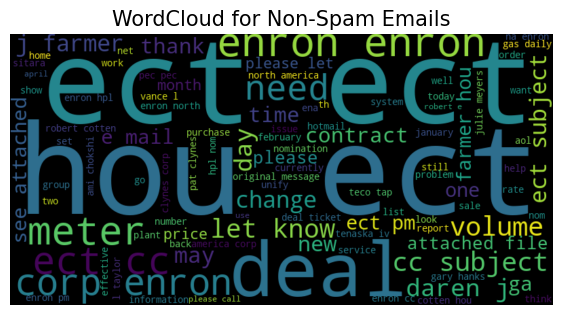

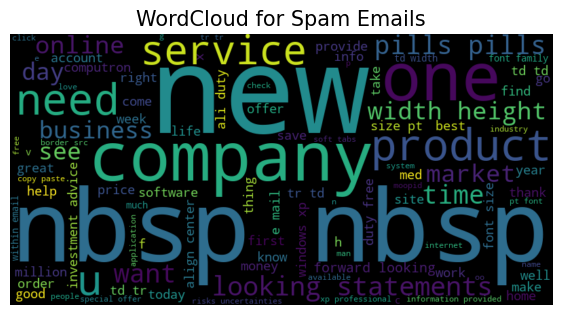

In [31]:
def plot_word_cloud(data, typ):
    email_corpus = " ".join(data['text'])
    wc = WordCloud(background_color='black', max_words=100, width=800, height=400).generate(email_corpus)
    plt.figure(figsize=(7, 7))
    plt.imshow(wc, interpolation='bilinear')
    plt.title(f'WordCloud for {typ} Emails', fontsize=15)
    plt.axis('off')
    plt.show()

plot_word_cloud(balanced_data[balanced_data['label'] == 'ham'], typ='Non-Spam')
plot_word_cloud(balanced_data[balanced_data['label'] == 'spam'], typ='Spam')

In [32]:
train_X, test_X, train_Y, test_Y = train_test_split(
    balanced_data['text'], balanced_data['label'], test_size=0.2, random_state=42
)

tokenizer = Tokenizer()
tokenizer.fit_on_texts(train_X)

train_sequences = tokenizer.texts_to_sequences(train_X)
test_sequences = tokenizer.texts_to_sequences(test_X)

max_len = 100  # Maximum sequence length
train_sequences = pad_sequences(train_sequences, maxlen=max_len, padding='post', truncating='post')
test_sequences = pad_sequences(test_sequences, maxlen=max_len, padding='post', truncating='post')

train_Y = (train_Y == 'spam').astype(int)
test_Y = (test_Y == 'spam').astype(int)

In [33]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Embedding(input_dim=len(tokenizer.word_index) + 1, output_dim=32, input_length=max_len),
    tf.keras.layers.LSTM(16),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')  # Output layer
])

model.compile(
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [34]:
es = EarlyStopping(patience=3, monitor='val_accuracy', restore_best_weights=True)
lr = ReduceLROnPlateau(patience=2, monitor='val_loss', factor=0.5, verbose=0)

history = model.fit(
    train_sequences, train_Y,
    validation_data=(test_sequences, test_Y),
    epochs=20,
    batch_size=32,
    callbacks=[lr, es]
)

Epoch 1/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.5317 - loss: 0.6857 - val_accuracy: 0.7633 - val_loss: 0.5968 - learning_rate: 0.0010
Epoch 2/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9299 - loss: 0.2721 - val_accuracy: 0.9483 - val_loss: 0.1914 - learning_rate: 0.0010
Epoch 3/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9616 - loss: 0.1579 - val_accuracy: 0.9533 - val_loss: 0.1863 - learning_rate: 0.0010
Epoch 4/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9512 - loss: 0.1970 - val_accuracy: 0.9367 - val_loss: 0.2353 - learning_rate: 0.0010
Epoch 5/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9662 - loss: 0.1466 - val_accuracy: 0.9433 - val_loss: 0.2198 - learning_rate: 0.0010
Epoch 6/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9796 - loss: 0.0969 - val_accuracy: 0.9567 - val_loss: 0.1817 - learning_rate: 5.0000e-04
Epoch 7/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9842 - loss: 0.0788 - val

In [35]:
test_loss, test_accuracy = model.evaluate(test_sequences, test_Y)
print('Test Loss :',test_loss)
print('Test Accuracy :',test_accuracy)

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9633 - loss: 0.1637
Test Loss : 0.16374754905700684
Test Accuracy : 0.9633333086967468


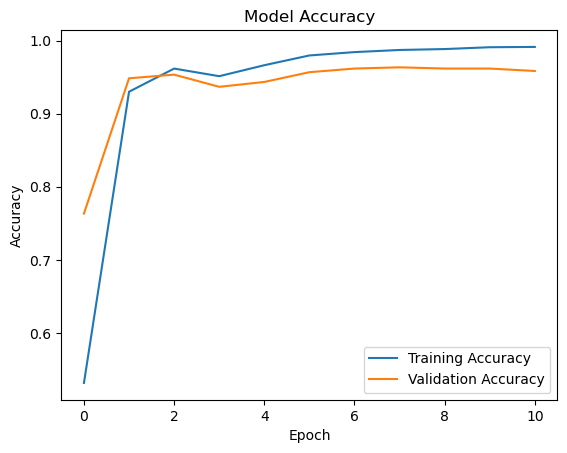

In [36]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.show()